In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [78]:
df = pd.read_csv("steam_games_dataset.csv")

df.head()

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819


In [79]:
Q1 = df['ccu'].quantile(0.25)
Q3 = df['ccu'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['ccu'] >= lower) & (df['ccu'] <= upper)]


In [80]:
X_simple = df[['average_forever']]
y = df['ccu']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train_s)

y_pred_simple = simple_lr.predict(X_test_s)

In [81]:
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)

print("Simple Linear Regression")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

Simple Linear Regression
MSE : 544.3862888951779
RMSE: 23.332087109711765
MAE : 16.163939905474177


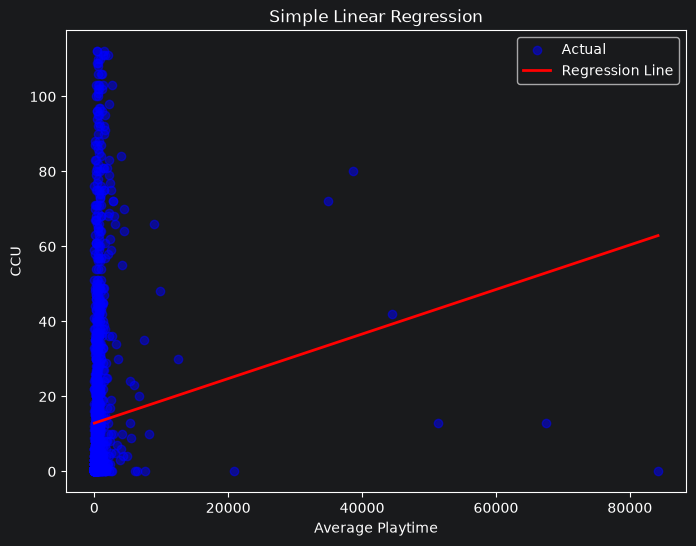

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test_s['average_forever'],
    y_test_s,
    color='blue',
    alpha=0.5,
    label='Actual'
)

# Sort values so the regression line is drawn correctly
sorted_idx = X_test_s['average_forever'].argsort()

plt.plot(
    X_test_s['average_forever'].iloc[sorted_idx],
    y_pred_simple[sorted_idx],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Average Playtime")
plt.ylabel("CCU")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

In [83]:
print("Intercept :", simple_lr.intercept_)
print("Coefficient :", simple_lr.coef_[0])

Intercept : 12.897889738831333
Coefficient : 0.0005939492507237425


In [84]:
features = [
    'positive',
    'negative',
    'userscore',
    'average_forever',
    'average_2weeks',
    'price',
    'discount'
]

X = df[features]
y = df['ccu']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
multiple_lr = LinearRegression()
multiple_lr.fit(X_train, y_train)
y_pred_multiple = multiple_lr.predict(X_test)

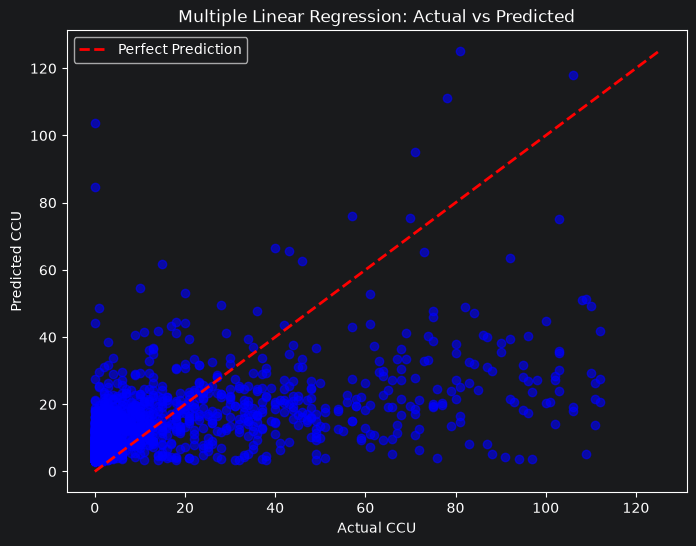

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_multiple,
    color='blue',
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_multiple.min())
max_val = max(y_test.max(), y_pred_multiple.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linewidth=2,
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual CCU")
plt.ylabel("Predicted CCU")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.legend()

plt.show()

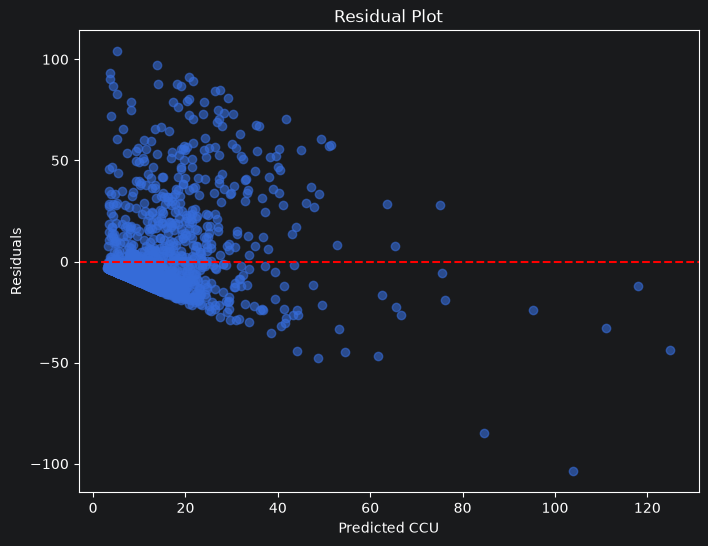

In [87]:
residuals = y_test - y_pred_multiple

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_multiple,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted CCU")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [88]:
mse = mean_squared_error(y_test, y_pred_multiple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_multiple)

print("Multiple Linear Regression")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

Multiple Linear Regression
MSE : 394.4794078452332
RMSE: 19.86150567920854
MAE : 12.653551589827202


In [89]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": multiple_lr.coef_
})

print(coefficients)

           Feature  Coefficient
0         positive     0.001437
1         negative    -0.000854
2        userscore     0.091305
3  average_forever     0.000478
4   average_2weeks     0.002982
5            price     0.005694
6         discount     0.081570


In [90]:
results = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MSE": [
        mean_squared_error(y_test, y_pred_simple),
        mean_squared_error(y_test, y_pred_multiple)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_simple)),
        np.sqrt(mean_squared_error(y_test, y_pred_multiple))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_simple),
        mean_absolute_error(y_test, y_pred_multiple)
    ]
})

print(results)

                        Model         MSE       RMSE        MAE
0    Simple Linear Regression  544.386289  23.332087  16.163940
1  Multiple Linear Regression  394.479408  19.861506  12.653552
